# glmnet-rs — a tour on two real datasets

[`glmnet-rs`](https://github.com/georgeberry/glmnet-rust) is a Rust port of the [glmnet](https://glmnet.stanford.edu) elastic-net solver, with a Python front end. Its coefficients match R glmnet to ~1e-13 (verified on the two datasets below).

We walk through the whole workflow — the lambda path, cross-validation, coefficient/CV plots, and prediction — on:

- **Wine Quality** (*long*: n=4898, p=11) — Gaussian regression.
- **Leukemia gene expression** (*wide*: n=72, p=7128) — binomial classification (ALL vs AML), the classic sparse-selection example.

In [1]:
%matplotlib inline
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from glmnetrs import glmnet, cv_glmnet

# Find the repo's datasets/ dir whether this runs from the repo root or examples/.
here = pathlib.Path.cwd()
while not (here / 'datasets').exists() and here != here.parent:
    here = here.parent
DATA = here / 'datasets'
print('datasets:', DATA)

datasets: /Users/georgeberry/Dropbox/rust-glmnet/datasets


## 1. Wine Quality — long, Gaussian

4898 white wines, 11 physicochemical measurements, predict the sensory `quality` score. glmnet standardizes the features internally.

In [2]:
raw = np.genfromtxt(DATA / 'winequality-white.csv', delimiter=';', names=True)
feat_names = [n for n in raw.dtype.names if n != 'quality']
Xw = np.column_stack([raw[n] for n in feat_names])
yw = raw['quality'].astype(float)
# z-score the features so coefficient paths are on a comparable scale and
# readable as importances (glmnet standardizes internally either way).
Xw = (Xw - Xw.mean(0)) / Xw.std(0)
print(f'X: {Xw.shape},  y range: {yw.min():.0f}..{yw.max():.0f}')
print('features:', ', '.join(feat_names))

X: (4898, 11),  y range: 3..9
features: fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, pH, sulphates, alcohol


### The lambda path
`glmnet` fits the *entire* regularization path in one call. `print` gives R's `Df / %Dev / Lambda` table (showing the first rows).

In [3]:
path = glmnet(Xw, yw)          # family='gaussian', alpha=1 (lasso) by default
print('\n'.join(path.summary().splitlines()[:12]))
print('...')
print(f'{path.lmu} lambdas fit; up to {100*path.dev_ratio[-1]:.1f}% deviance explained')

        Df    %Dev      Lambda
   1     0    0.00      0.3857
   2     1    3.22      0.3515
   3     1    5.90      0.3202
   4     1    8.12      0.2918
   5     1    9.96      0.2659
   6     1   11.49      0.2422
   7     1   12.76      0.2207
   8     1   13.81      0.2011
   9     2   14.84      0.1832
  10     2   16.40       0.167
  11     2   17.69      0.1521
...
78 lambdas fit; up to 28.2% deviance explained


Each line is one coefficient's trajectory as the penalty relaxes (left = strong penalty, everything zero; right = weak penalty). The top axis is the number of nonzero coefficients.

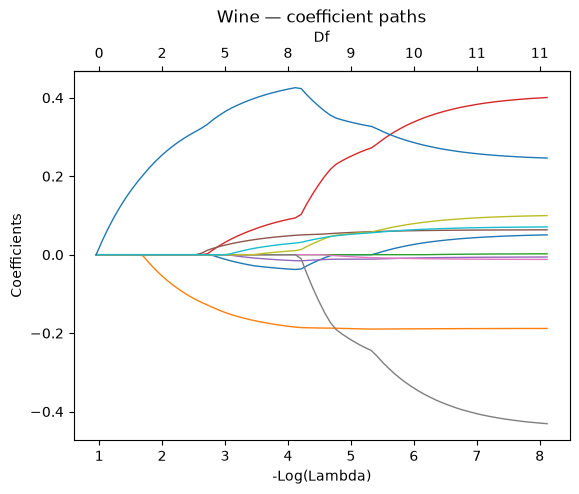

In [4]:
ax = path.plot(xvar='lambda'); ax.set_title('Wine — coefficient paths'); plt.show()

### Cross-validation to pick lambda
`cv_glmnet` mirrors R's `cv.glmnet`: it reports `lambda.min` (best CV error) and `lambda.1se` (the most regularized model within one standard error — the usual choice for a parsimonious fit).

Measure: Mean-Squared Error
        Lambda  Index    Measure       SE  Nonzero
min   0.002538     55      0.568   0.0104       10
1se    0.02367     31      0.578  0.00966        8


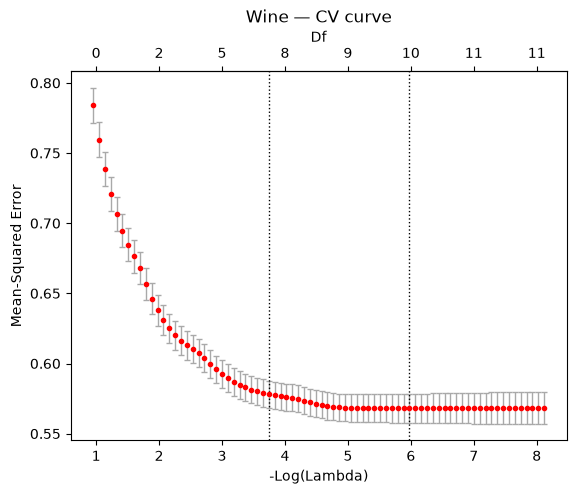

In [5]:
cvw = cv_glmnet(Xw, yw, type_measure='mse', nfolds=10, seed=1)
print(cvw)
ax = cvw.plot(); ax.set_title('Wine — CV curve'); plt.show()

### What the model selected
Coefficients at `lambda.1se` (standardized features, so magnitudes are directly comparable as importances). The signs line up with wine intuition — higher **alcohol** predicts higher quality, higher **volatile acidity** predicts lower.

In [6]:
coef = cvw.coef(s='lambda.1se').ravel()
intercept, betas = coef[0], coef[1:]
order = np.argsort(-np.abs(betas))
print(f'intercept: {intercept:.3f}')
for j in order:
    if betas[j] != 0:
        print(f'  {feat_names[j]:24s} {betas[j]:+.3f}')
print(f'\n{np.count_nonzero(betas)} of {len(betas)} features used')

intercept: 5.878
  alcohol                  +0.412
  volatile_acidity         -0.176
  residual_sugar           +0.080
  free_sulfur_dioxide      +0.044
  fixed_acidity            -0.033
  sulphates                +0.023
  chlorides                -0.012
  pH                       +0.005

8 of 11 features used


### Held-out accuracy
Fit on a train split, evaluate RMSE on the test split at both lambdas, and compare to ordinary least squares. The `lambda.1se` model is more compact and generalizes about as well.

In [7]:
rng = np.random.default_rng(0)
idx = rng.permutation(len(yw)); cut = int(0.8 * len(yw))
tr, te = idx[:cut], idx[cut:]
cv_tr = cv_glmnet(Xw[tr], yw[tr], type_measure='mse', nfolds=10, seed=2)

def rmse(pred):
    return float(np.sqrt(np.mean((yw[te] - pred) ** 2)))

rmse_min = rmse(cv_tr.predict(Xw[te], s='lambda.min').ravel())
rmse_1se = rmse(cv_tr.predict(Xw[te], s='lambda.1se').ravel())
# plain OLS for reference
A = np.column_stack([np.ones(len(tr)), Xw[tr]])
beta_ols, *_ = np.linalg.lstsq(A, yw[tr], rcond=None)
rmse_ols = rmse(np.column_stack([np.ones(len(te)), Xw[te]]) @ beta_ols)
print(f'test RMSE  lasso(min): {rmse_min:.4f}   lasso(1se): {rmse_1se:.4f}   OLS: {rmse_ols:.4f}')
nz_1se = np.count_nonzero(cv_tr.coef(s='lambda.1se').ravel()[1:])
print(f'lambda.1se uses {nz_1se} features vs OLS\'s {Xw.shape[1]}')

test RMSE  lasso(min): 0.7940   lasso(1se): 0.8005   OLS: 0.7923
lambda.1se uses 7 features vs OLS's 11


## 2. Leukemia — wide, binomial

The Golub et al. (1999) benchmark: 72 patients, 7128 gene-expression values, classify **ALL vs AML**. With `p ≫ n`, the lasso's job is to find a *handful* of genes that separate the classes — the canonical glmnet story.

In [8]:
with open(DATA / 'leukemia_big.csv') as fh:
    labels = np.array(fh.readline().strip().split(','))
expr = np.loadtxt(DATA / 'leukemia_big.csv', delimiter=',', skiprows=1)
Xl = expr.T                       # samples x genes
yl = (labels == 'AML').astype(float)
print(f'X: {Xl.shape}   ALL: {int((yl==0).sum())}, AML: {int((yl==1).sum())}')

X: (72, 7128)   ALL: 47, AML: 25


100 lambdas; nonzero genes range 0..31


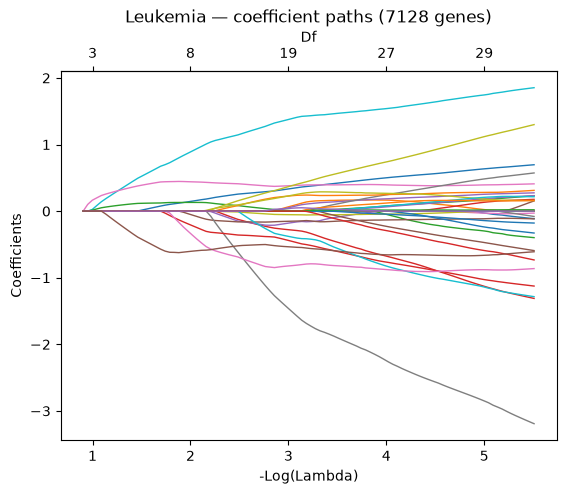

In [9]:
lpath = glmnet(Xl, yl, family='binomial')
print(f'{lpath.lmu} lambdas; nonzero genes range {lpath.df.min()}..{lpath.df.max()}')
ax = lpath.plot(xvar='lambda'); ax.set_title('Leukemia — coefficient paths (7128 genes)'); plt.show()

Only a few of the 7128 genes ever leave zero. Cross-validate on misclassification error (6 folds, so ~12 samples per fold).

Measure: Misclassification Error
        Lambda  Index    Measure       SE  Nonzero
min   0.005352     94    0.04167   0.0285       30
1se     0.1924     17    0.06944   0.0256        5


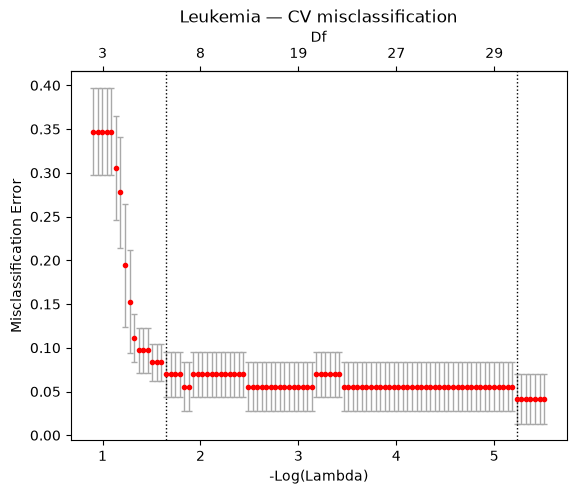

In [10]:
cvl = cv_glmnet(Xl, yl, family='binomial', type_measure='class', nfolds=6, seed=1)
print(cvl)
ax = cvl.plot(); ax.set_title('Leukemia — CV misclassification'); plt.show()

### A sparse gene signature
At `lambda.1se`, a small set of genes classifies the training data — and their linear predictor cleanly separates ALL from AML.

5 genes selected at lambda.1se:  [1833, 1881, 2287, 3251, 6853]
training accuracy with 5 genes: 95.8%


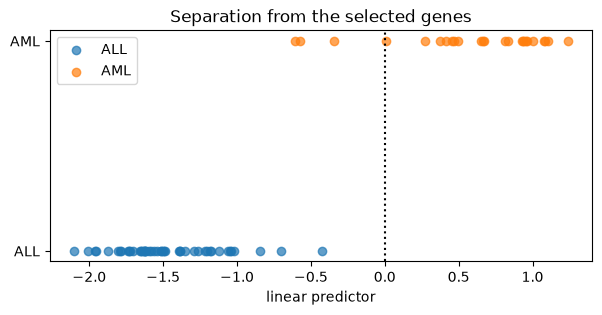

In [11]:
genes = np.flatnonzero(cvl.coef(s='lambda.1se').ravel()[1:] != 0)
print(f'{len(genes)} genes selected at lambda.1se:  {genes.tolist()}')

prob = cvl.predict(Xl, s='lambda.1se', type='response').ravel()
pred = (prob > 0.5).astype(float)
acc = (pred == yl).mean()
print(f'training accuracy with {len(genes)} genes: {acc:.1%}')

fig, ax = plt.subplots(figsize=(7, 3))
eta = cvl.predict(Xl, s='lambda.1se', type='link').ravel()
ax.scatter(eta[yl == 0], np.zeros((yl == 0).sum()), label='ALL', alpha=.7)
ax.scatter(eta[yl == 1], np.ones((yl == 1).sum()), label='AML', alpha=.7)
ax.axvline(0, ls=':', c='k'); ax.set_yticks([0, 1]); ax.set_yticklabels(['ALL', 'AML'])
ax.set_xlabel('linear predictor'); ax.set_title('Separation from the selected genes'); ax.legend()
plt.show()

## 3. scikit-learn interface

For pipelines/grid-search, `glmnet.sklearn` exposes estimators with scikit-learn's parameter names (`alpha` = penalty strength, `l1_ratio` = mixing) — the conversion to glmnet's convention (including the subtle `ys` factor on the L2 term) is handled for you.

In [12]:
from glmnetrs.sklearn import ElasticNet, LogisticRegression
en = ElasticNet(alpha=0.1, l1_ratio=0.5).fit(Xw, yw)
clf = LogisticRegression(C=1.0).fit(Xl, yl)
print('ElasticNet nonzero coefs:', int(np.count_nonzero(en.coef_)))
print('LogisticRegression train accuracy:', f'{clf.score(Xl, yl):.1%}')

ElasticNet nonzero coefs: 6
LogisticRegression train accuracy: 100.0%


---
That's the tour: same API as R glmnet, matching coefficients, plus a scikit-learn shim. See [`docs/ROADMAP.md`](../docs/ROADMAP.md) for what's implemented and what's next.